In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [2]:
df = pd.read_csv('../data/enriched/telco_churn_enriched.csv')

In [3]:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [4]:
df.drop(columns=['customerID','Churn'], inplace = True)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [6]:
df[df['TotalCharges'].isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Total_Services,Churn_Numeric
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,...,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,4,0
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,0,0
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,...,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,5,0
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,0,0
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,...,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,5,0
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,0,0
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,0,0
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,0,0
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,0,0
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,...,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,4,0


In [7]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

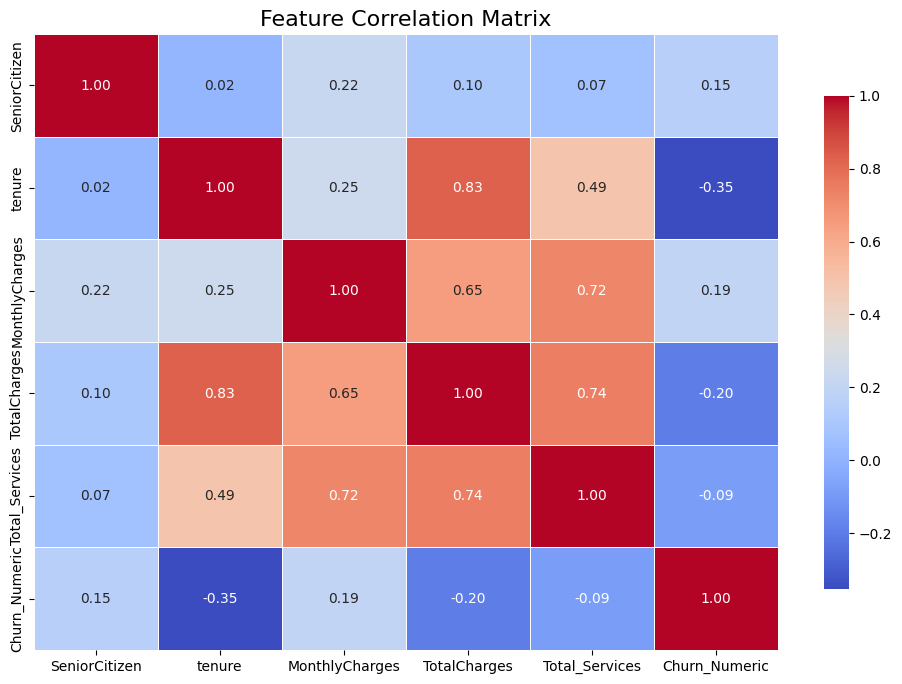

In [8]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=16)
plt.show()

In [9]:
categorical_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
                    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
                    'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [10]:
df.head().T

,0,1,2,3,4
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
PaperlessBilling,Yes,No,Yes,No,Yes
MonthlyCharges,29.85,56.95,53.85,42.3,70.7
TotalCharges,29.85,1889.5,108.15,1840.75,151.65
Total_Services,1,2,2,3,0


In [11]:
df = df.astype({col: 'int64' for col in df.select_dtypes('bool').columns})

In [12]:
df.head().T

,0,1,2,3,4
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
PaperlessBilling,Yes,No,Yes,No,Yes
MonthlyCharges,29.85,56.95,53.85,42.3,70.7
TotalCharges,29.85,1889.5,108.15,1840.75,151.65
Total_Services,1,2,2,3,0


In [13]:
df = pd.get_dummies(df, columns=['gender'], drop_first=True)

In [14]:
df.replace({True: 1, False: 0}, inplace=True)
df.replace({'Yes': 1, 'No': 0}, inplace=True)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Total_Services,Churn_Numeric,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,gender_Male
0,0,1,0,1,0,1,29.85,29.85,1,0,...,0,0,0,0,0,0,0,1,0,0
1,0,0,0,34,1,0,56.95,1889.50,2,0,...,0,0,0,0,1,0,0,0,1,1
2,0,0,0,2,1,1,53.85,108.15,2,1,...,0,0,0,0,0,0,0,0,1,1
3,0,0,0,45,0,0,42.30,1840.75,3,0,...,0,0,0,0,1,0,0,0,0,1
4,0,0,0,2,1,1,70.70,151.65,0,1,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,1,24,1,1,84.80,1990.50,5,0,...,0,1,0,1,1,0,0,0,1,1
7039,0,1,1,72,1,1,103.20,7362.90,4,0,...,0,1,0,1,1,0,1,0,0,0
7040,0,1,1,11,0,1,29.60,346.45,1,0,...,0,0,0,0,0,0,0,1,0,0
7041,1,1,0,4,1,1,74.40,306.60,0,1,...,0,0,0,0,0,0,0,0,1,1


In [15]:
df.head().T

,0,1,2,3,4
SeniorCitizen,0,0,0,0,0
Partner,1,0,0,0,0
Dependents,0,0,0,0,0
tenure,1,34,2,45,2
PhoneService,0,1,1,0,1
PaperlessBilling,1,0,1,0,1
MonthlyCharges,29.85,56.95,53.85,42.3,70.7
TotalCharges,29.85,1889.5,108.15,1840.75,151.65
Total_Services,1,2,2,3,0
Churn_Numeric,0,0,1,0,1


In [16]:
df['Partner'] = df['Partner'].astype(int)
df['Dependents'] = df['Dependents'].astype(int)
df['PhoneService'] = df['PhoneService'].astype(int)
df['PaperlessBilling'] = df['PaperlessBilling'].astype(int)
df['gender_Male'] = df['gender_Male'].astype(int)

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   Partner                                7043 non-null   int64  
 2   Dependents                             7043 non-null   int64  
 3   tenure                                 7043 non-null   int64  
 4   PhoneService                           7043 non-null   int64  
 5   PaperlessBilling                       7043 non-null   int64  
 6   MonthlyCharges                         7043 non-null   float64
 7   TotalCharges                           7043 non-null   float64
 8   Total_Services                         7043 non-null   int64  
 9   Churn_Numeric                          7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  MultipleLines_Y

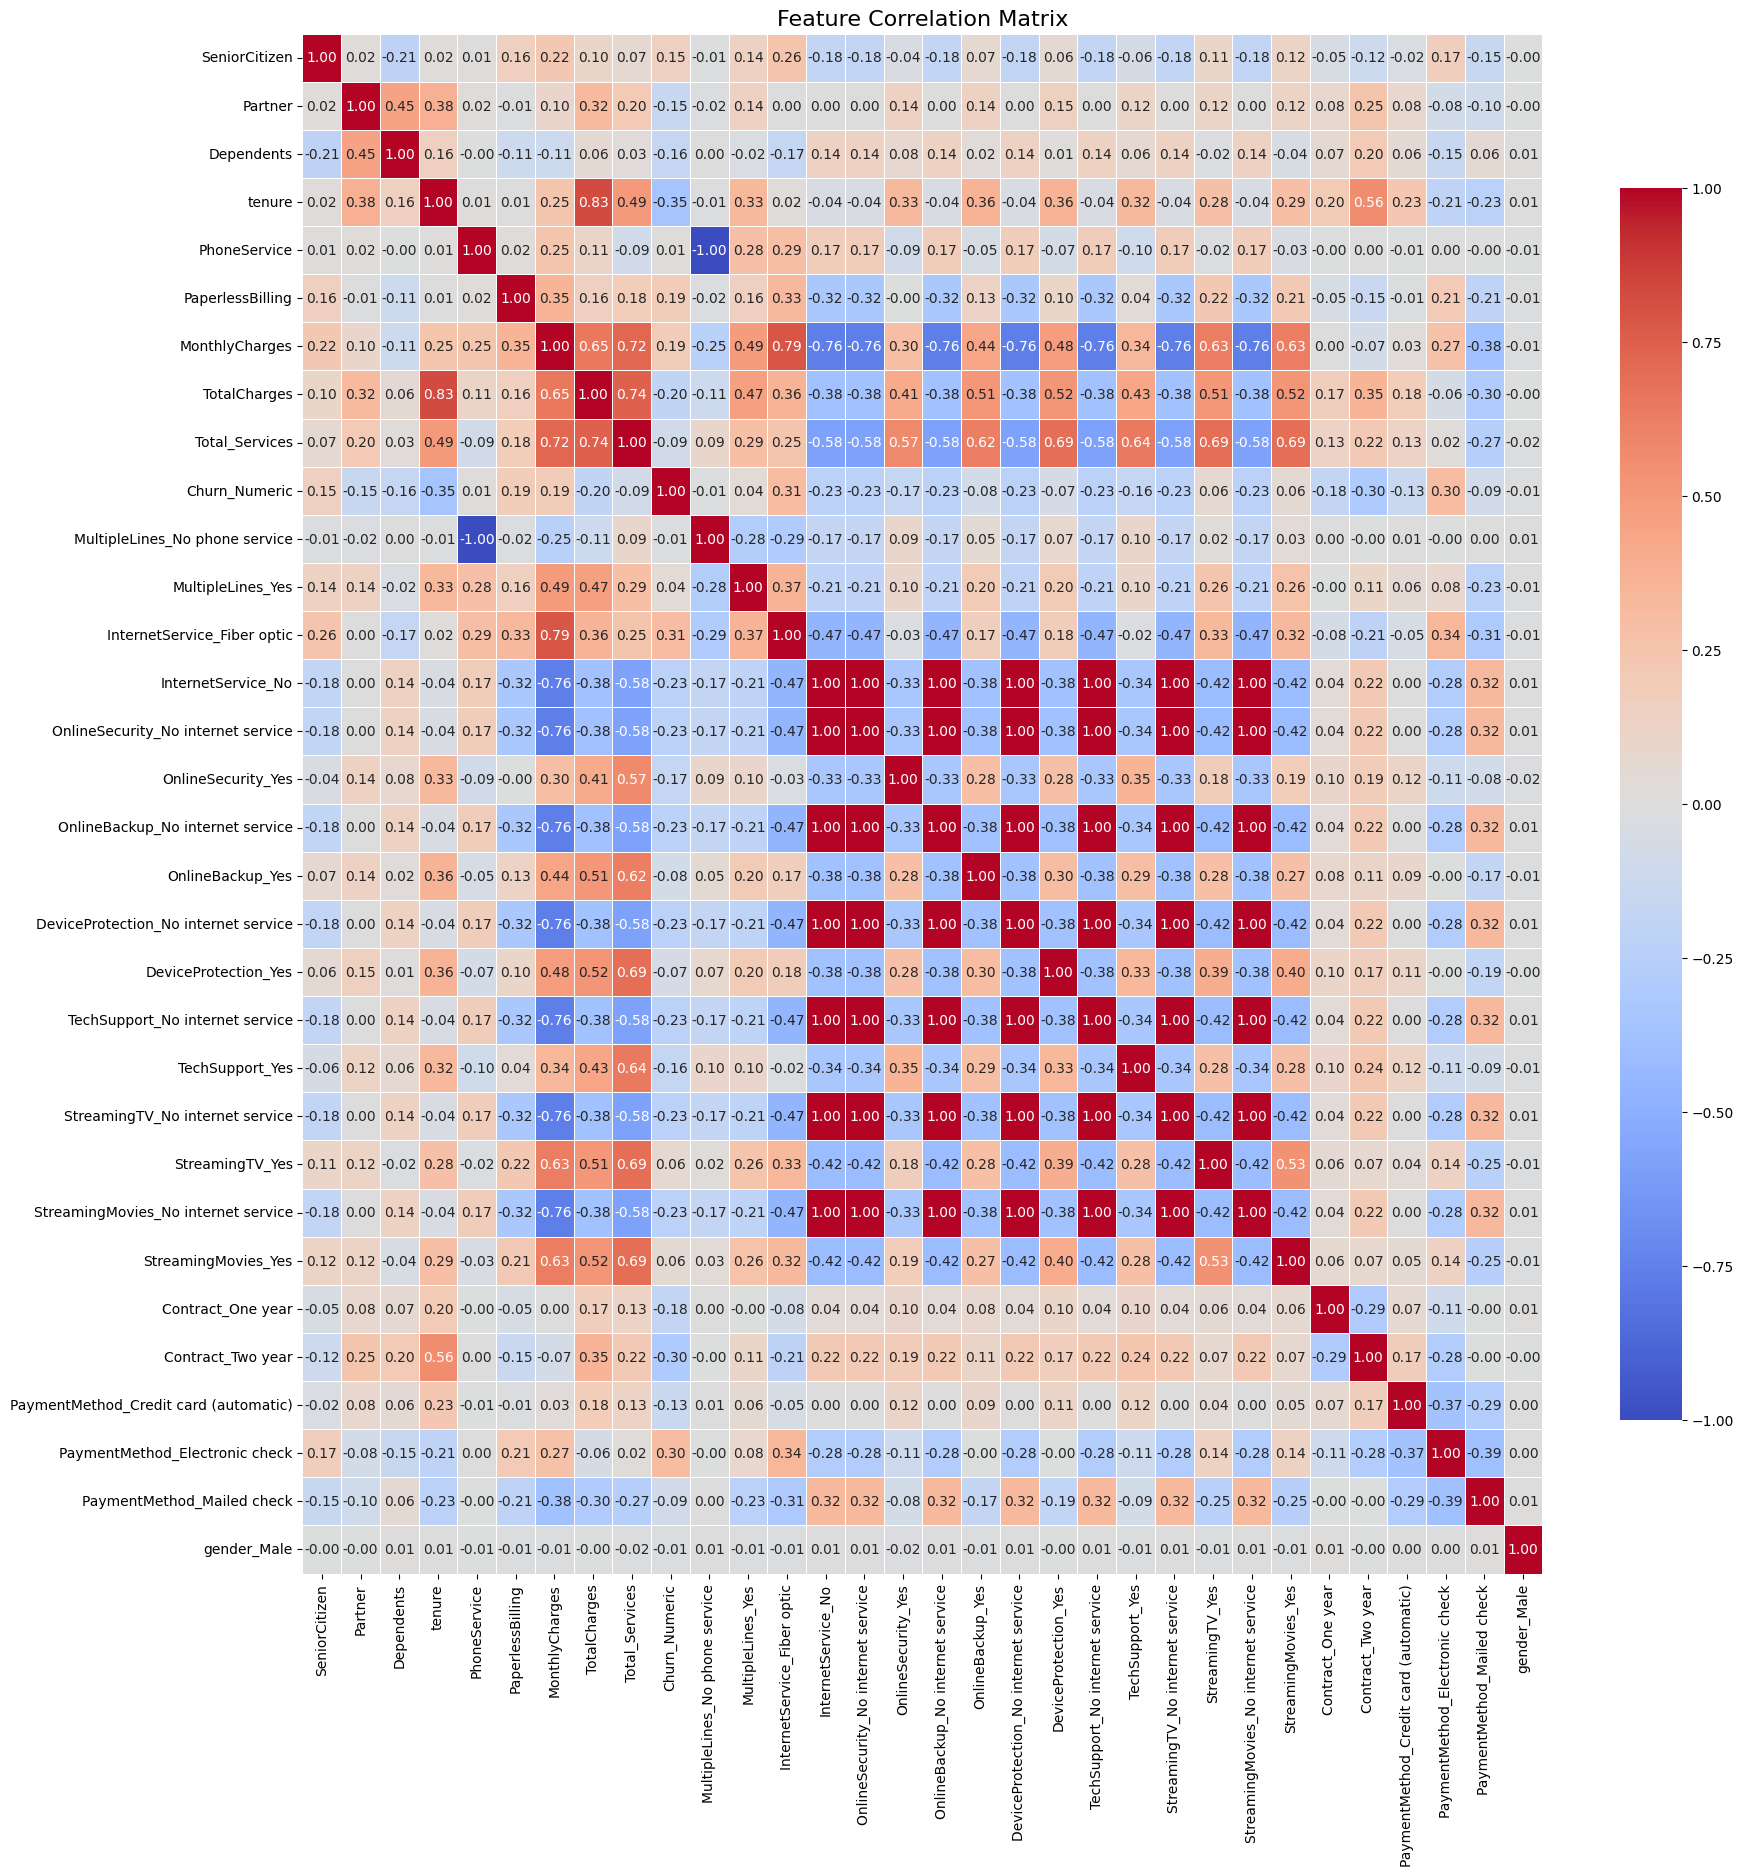

In [18]:
corr_matrix = df.corr()

plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=16)
plt.show()

In [19]:
# 1. Create a temporary dataframe with only your predictors
# We exclude the target so it doesn't skew the multicollinearity check
features_to_check = df.drop(columns=['Churn_Numeric'])

# 2. Add a constant (Intercept) - VIF math requires this for accuracy
features_with_constant = features_to_check.assign(const=1)

# 3. Calculate VIF
vif_data = pd.DataFrame()
vif_data['Features'] = features_with_constant.columns
vif_data['VIF'] = [
    variance_inflation_factor(features_with_constant.values, i) 
    for i in range(features_with_constant.shape[1])
]

# 4. Display results sorted by highest VIF
print(vif_data.sort_values(by='VIF', ascending=False))


                                 Features         VIF
4                            PhoneService         inf
13     OnlineSecurity_No internet service         inf
15       OnlineBackup_No internet service         inf
14                     OnlineSecurity_Yes         inf
12                     InternetService_No         inf
8                          Total_Services         inf
9          MultipleLines_No phone service         inf
24                    StreamingMovies_Yes         inf
23    StreamingMovies_No internet service         inf
22                        StreamingTV_Yes         inf
21        StreamingTV_No internet service         inf
20                        TechSupport_Yes         inf
19        TechSupport_No internet service         inf
18                   DeviceProtection_Yes         inf
17   DeviceProtection_No internet service         inf
16                       OnlineBackup_Yes         inf
6                          MonthlyCharges  865.062147
11            InternetServic

In [20]:
df.to_csv('../data/processed/telco_churn_more.csv', index=False)

In [21]:
cols_to_drop = [
    'OnlineSecurity_No internet service',
    'OnlineBackup_No internet service',
    'DeviceProtection_No internet service',
    'TechSupport_No internet service',
    'StreamingTV_No internet service',
    'StreamingMovies_No internet service',
    'PhoneService',     
    'MonthlyCharges',   
    'TotalCharges',     
    'Total_Services',   
    'gender_Male'
]

df.drop(columns=cols_to_drop, inplace=True)

In [22]:
df.to_csv('../data/processed/telco_churn_clean.csv', index=False)

In [23]:
features_to_check = df.drop(columns=['Churn_Numeric'])

features_with_constant = features_to_check.assign(const=1)

vif_data = pd.DataFrame()
vif_data['Features'] = features_with_constant.columns
vif_data['VIF'] = [
    variance_inflation_factor(features_with_constant.values, i) 
    for i in range(features_with_constant.shape[1])
]

print(vif_data.sort_values(by='VIF', ascending=False))

                                 Features        VIF
20                                  const  15.362936
3                                  tenure   2.783683
8                      InternetService_No   2.698153
16                      Contract_Two year   2.613785
7             InternetService_Fiber optic   2.006111
18         PaymentMethod_Electronic check   1.973418
19             PaymentMethod_Mailed check   1.840374
14                    StreamingMovies_Yes   1.633839
13                        StreamingTV_Yes   1.626075
15                      Contract_One year   1.621934
17  PaymentMethod_Credit card (automatic)   1.560168
12                        TechSupport_Yes   1.482076
11                   DeviceProtection_Yes   1.481022
1                                 Partner   1.462036
6                       MultipleLines_Yes   1.421493
9                      OnlineSecurity_Yes   1.415310
2                              Dependents   1.383490
10                       OnlineBackup_Yes   1.

In [24]:
# Final check of Churn vs No-Churn ratio
print("Final Target Distribution:")
print(df['Churn_Numeric'].value_counts(normalize=True))

Final Target Distribution:
Churn_Numeric
0    0.73463
1    0.26537
Name: proportion, dtype: float64
